# ER 图随机基准：cd_A_noepoch / greedy_cd_noepoch / NOTEARS / FGES / GOLEM-EV

随机生成 ER 图，对比以下算法：

- **cd_A_noepoch** (λ=0.0 / 0.1 / 0.2)：坐标下降（非 epoch），via `coordinate_descent.coordinate0`
- **greedy_cd_noepoch** (λ=0.0 / 0.1 / 0.2)：贪婪坐标下降（非 epoch），via `coordinate_descent.cd_greedy_A`
- **NOTEARS**：连续松弛 + 增广拉格朗日，via `gcastle`
- **FGES**：Fast Greedy Equivalence Search，via `pytetrad`（需 JDK 21+）
- **GOLEM-EV**：等方差假设 GOLEM，via `golemMain/src/golem.py`

每个算法在独立 cell 中执行；结果在最后汇总比较。

In [1]:
# 1) 环境与导入
import os
import sys
import time
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 仓库根目录 ────────────────────────────────────────────────────────────────
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
if not os.environ.get('JAVA_HOME'):
    _jdk_candidate = r'C:\Program Files\Microsoft\jdk-21.0.10.7-hotspot'
    if os.path.isdir(_jdk_candidate):
        os.environ['JAVA_HOME'] = _jdk_candidate


print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)

# ── 核心依赖 ──────────────────────────────────────────────────────────────────
from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset

# ── cd_A (non-epoch) ──────────────────────────────────────────────────────────
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_A_noepoch

# ── Greedy-CD (non-epoch) ─────────────────────────────────────────────────────
try:
    from coordinate_descent.cd_greedy_A import dag_greedy_A as greedy_cd_noepoch_fit
    HAS_GREEDY_CD = True
    print('Greedy-CD : OK')
except Exception as _e:
    HAS_GREEDY_CD = False
    print('Greedy-CD unavailable:', _e)

# ── NOTEARS (gcastle) ─────────────────────────────────────────────────────────
NOTEARS_IMPORT_ERROR = None
try:
    logging.disable(logging.INFO)
    from castle.algorithms import Notears as _Notears
    logging.disable(logging.NOTSET)
    HAS_NOTEARS = True
    print('NOTEARS   : OK')
except Exception as _e:
    logging.disable(logging.NOTSET)
    HAS_NOTEARS = False
    NOTEARS_IMPORT_ERROR = _e
    print('NOTEARS unavailable:', _e)

# ── FGES (pytetrad, requires JDK 21+) ────────────────────────────────────────
FGES_IMPORT_ERROR = None
try:
    import fges_compat as _ts
    _probe = pd.DataFrame(np.eye(2), columns=['x0', 'x1'])
    _s = _ts.TetradSearch(_probe)
    _s.set_verbose(False)
    _s.use_sem_bic()
    _s.run_fges()
    del _probe, _s
    HAS_FGES = True
    print('FGES      : OK')
except Exception as _e:
    HAS_FGES = False
    FGES_IMPORT_ERROR = _e
    print('FGES unavailable:', _e)

# ── GOLEM ─────────────────────────────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    _golem_src = os.path.join(repo_root, 'golemMain', 'src')
    if _golem_src not in sys.path:
        sys.path.append(_golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM     : OK')
except Exception as _e:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = _e
    print('GOLEM unavailable:', _e)

# ── CPDAG-SHD backend (optional) ─────────────────────────────────────────────
try:
    _tb = os.path.join(repo_root, 'toolbox')
    if _tb not in sys.path:
        sys.path.append(_tb)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable (fallback):', _e)


Python   : 3.10.11
Repo root: c:\Users\super\DAG
c:\Users\super\DAG\experiments\notebooks\test
Greedy-CD : OK
NOTEARS   : OK
FGES      : OK


2026-03-31 16:30:13,057 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From C:\Users\super\AppData\Roaming\Python\Python310\site-packages\keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.

2026-03-31 16:30:15,551 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From c:\Users\super\DAG\golemMain\src\models\golem_model.py:4: The name tf.disable_eager_execution is deprecated. Please use tf.compat.v1.disable_eager_execution instead.



GOLEM     : OK
CPDAG-SHD backend unavailable (fallback): No module named 'GPUtil'


In [3]:
# 2) 辅助函数

def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est  = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff    = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    G_true = np.asarray(G_true, dtype=int)
    G_est  = np.asarray(G_est,  dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def fges_matrix_to_adj(df_result) -> np.ndarray:
    """pytetrad get_graph_to_matrix() -> 0/1 adjacency (ARROW=2, TAIL=3)."""
    mat = df_result.values
    d   = mat.shape[0]
    G   = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = int(mat[i, j]), int(mat[j, i])
            if   a == 2 and b == 3: G[i, j] = 1
            elif a == 3 and b == 2: G[j, i] = 1
            elif a == 3 and b == 3: G[i, j] = G[j, i] = 1
            elif a != 0 or  b != 0: G[i, j] = G[j, i] = 1
    np.fill_diagonal(G, 0)
    return G


def _make_row(d, n, trial_id, seed, alg, runtime_sec, G_true, G_est):
    mec  = int(is_in_markov_equiv_class(G_true, G_est))
    shd  = shd_score(G_true, G_est)
    cshd = cpdag_shd_score(G_true, G_est)
    return {
        'd': d, 'n_samples': n, 'trial_id': trial_id, 'seed': seed,
        'algorithm': alg,
        'mec_match': mec,
        'shd': shd,
        'cpdag_shd': cshd,
        'n_edges_true': int(G_true.sum()),
        'n_edges_est':  int(G_est.sum()),
        'runtime_sec': float(runtime_sec),
    }


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    return (
        df.groupby(['algorithm', 'd', 'n_samples'], as_index=False)
        .agg(
            mec_match_mean   = ('mec_match',   'mean'),
            shd_mean         = ('shd',         'mean'),
            cpdag_shd_mean   = ('cpdag_shd',   'mean'),
            runtime_sec_mean = ('runtime_sec', 'mean'),
            trials           = ('trial_id',    'count'),
        )
    )


# 各算法 cell 将结果追加到这个全局列表
_ALL_ROWS: list = []
_SKIP_LOGS: list = []

print('辅助函数已定义。')


辅助函数已定义。


In [21]:
# 3) 实验配置
CFG = {
    # ── ER 图参数 ────────────────────────────────────────────────────────────
    'trials':       3,            # 每组 (d, n) 重复次数
    'seed':         42,
    'd_list':       [20, 30, 40, 50], # 节点数
    'n_list':       [20000], # 样本量
    'degree':       3.0,          # ER 图期望度
    'noise_type':   'gaussian_nv',
    'b_scale':      1.0,

    # ── 通用 ──────────────────────────────────────────────────────────────
    'threshold':    0.05,

    # ── cd_A_noepoch / greedy_cd_noepoch 参数 ──────────────────────────────
    'T_noepoch':      100000,           # 坐标下降步数上限
    'lambda_l0_list': [0.0, 0.1, 0.2],

    # ── NOTEARS ───────────────────────────────────────────────────────────
    'notears_lambda1':    0.1,
    'notears_loss_type':  'l2',
    'notears_threshold':  0.3,

    # ── FGES ──────────────────────────────────────────────────────────────
    'fges_penalty_discount': 1.0,

    # ── GOLEM ─────────────────────────────────────────────────────────────
    'golem_num_iter':      100000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1_ev':    2e-2,
    'golem_lambda2':       5.0,

    # ── 输出 ──────────────────────────────────────────────────────────────
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag':     'er_benchmark_20260330',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

ALGORITHM_ORDER = [
    'cd_A_noepoch_l0_0.0',      'cd_A_noepoch_l0_0.1',      'cd_A_noepoch_l0_0.2',
    'greedy_cd_noepoch_l0_0.0', 'greedy_cd_noepoch_l0_0.1', 'greedy_cd_noepoch_l0_0.2',
    'notears',
    'fges',
    'golem_ev',
]

# ALGORITHM_ORDER = [
#     'cd_A_noepoch_l0_0.0',      'cd_A_noepoch_l0_0.1',      'cd_A_noepoch_l0_0.2',
#     'greedy_cd_noepoch_l0_0.0', 'greedy_cd_noepoch_l0_0.1', 'greedy_cd_noepoch_l0_0.2',
#     'notears',
#     'fges',
#     'golem_ev',
# ]

print('配置完成。')
print(f"  d_list   : {CFG['d_list']}")
print(f"  n_list   : {CFG['n_list']}")
print(f"  trials   : {CFG['trials']}")
print(f"  算法列表 ({len(ALGORITHM_ORDER)} 个):")
for _a in ALGORITHM_ORDER:
    print(f'    {_a}')


配置完成。
  d_list   : [20, 30, 40, 50]
  n_list   : [20000]
  trials   : 3
  算法列表 (9 个):
    cd_A_noepoch_l0_0.0
    cd_A_noepoch_l0_0.1
    cd_A_noepoch_l0_0.2
    greedy_cd_noepoch_l0_0.0
    greedy_cd_noepoch_l0_0.1
    greedy_cd_noepoch_l0_0.2
    notears
    fges
    golem_ev


In [10]:
# 4) 通用 ER 图 trial 生成器
# 各算法 cell 调用 _iter_trials(CFG) 来统一遍历 (d, n, trial) 三元组

def _iter_trials(cfg: dict):
    """生成器：依次产出 (d, n, trial_id, seed, X, S, G_true)。"""
    rng = np.random.default_rng(cfg['seed'])
    for d in cfg['d_list']:
        for n in cfg['n_list']:
            seeds = rng.integers(0, 10**9, size=cfg['trials'])
            for trial_idx, seed in enumerate(seeds, start=1):
                dataset = SyntheticDataset(
                    n=n, d=d,
                    graph_type='ER',
                    degree=cfg['degree'],
                    noise_type=cfg['noise_type'],
                    B_scale=cfg['b_scale'],
                    seed=int(seed),
                )
                X      = dataset.X
                S      = X.T @ X / X.shape[0]
                G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
                yield d, n, trial_idx, int(seed), X, S, G_true


print('ER trial 生成器已定义。')


ER trial 生成器已定义。


In [22]:
# 5) cd_A_noepoch  (lambda = 0.0 / 0.1 / 0.2)
# ──────────────────────────────────────────────────────────────────────────────

_rows_cd_A_noepoch = []

for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
    for _lam in CFG['lambda_l0_list']:
        _alg = f'cd_A_noepoch_l0_{_lam:.1f}'
        try:
            _t0 = time.perf_counter()
            _, _G_est, _ = cd_A_noepoch(
                S=_S, T=CFG['T_noepoch'], seed=_seed,
                threshold=CFG['threshold'], lambda_l0=_lam,
            )
            _rt  = time.perf_counter() - _t0
            _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_cd_A_noepoch.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[{_alg}] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_cd_A_noepoch  = pd.DataFrame(_rows_cd_A_noepoch)
df_summary_cd_A_noepoch = summarize(df_trials_cd_A_noepoch)
print('\ncd_A_noepoch summary:')
display(df_summary_cd_A_noepoch)


[cd_A_noepoch_l0_0.0] d=20 n=20000 trial=1  mec=0  shd=21  cpdag_shd=58  rt=61.832s
[cd_A_noepoch_l0_0.1] d=20 n=20000 trial=1  mec=0  shd=31  cpdag_shd=78  rt=40.159s
[cd_A_noepoch_l0_0.2] d=20 n=20000 trial=1  mec=0  shd=27  cpdag_shd=67  rt=40.585s
[cd_A_noepoch_l0_0.0] d=20 n=20000 trial=2  mec=0  shd=18  cpdag_shd=33  rt=51.514s
[cd_A_noepoch_l0_0.1] d=20 n=20000 trial=2  mec=0  shd=8  cpdag_shd=11  rt=42.241s
[cd_A_noepoch_l0_0.2] d=20 n=20000 trial=2  mec=0  shd=13  cpdag_shd=23  rt=40.915s
[cd_A_noepoch_l0_0.0] d=20 n=20000 trial=3  mec=0  shd=24  cpdag_shd=64  rt=50.584s
[cd_A_noepoch_l0_0.1] d=20 n=20000 trial=3  mec=0  shd=16  cpdag_shd=40  rt=41.001s
[cd_A_noepoch_l0_0.2] d=20 n=20000 trial=3  mec=0  shd=15  cpdag_shd=38  rt=42.388s
[cd_A_noepoch_l0_0.0] d=30 n=20000 trial=1  mec=0  shd=88  cpdag_shd=314  rt=79.580s
[cd_A_noepoch_l0_0.1] d=30 n=20000 trial=1  mec=0  shd=50  cpdag_shd=151  rt=52.427s
[cd_A_noepoch_l0_0.2] d=30 n=20000 trial=1  mec=0  shd=39  cpdag_shd=105  r

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_l0_0.0,20,20000,0.0,21.000000,51.666667,54.643398,3
1,cd_A_noepoch_l0_0.0,30,20000,0.0,59.666667,195.666667,78.933009,3
2,cd_A_noepoch_l0_0.0,40,20000,0.0,88.333333,364.333333,126.116873,3
3,cd_A_noepoch_l0_0.0,50,20000,0.0,162.333333,958.000000,173.552464,3
4,cd_A_noepoch_l0_0.1,20,20000,0.0,18.333333,43.000000,41.133788,3
5,cd_A_noepoch_l0_0.1,30,20000,0.0,40.000000,117.333333,51.425173,3
6,cd_A_noepoch_l0_0.1,40,20000,0.0,46.666667,133.666667,72.798658,3
7,cd_A_noepoch_l0_0.1,50,20000,0.0,104.000000,346.000000,90.345569,3
8,cd_A_noepoch_l0_0.2,20,20000,0.0,18.333333,42.666667,41.295857,3
9,cd_A_noepoch_l0_0.2,30,20000,0.0,36.333333,90.666667,52.341502,3


In [ ]:
# # 6) greedy_cd_noepoch  (lambda = 0.0 / 0.1 / 0.2)
# # ──────────────────────────────────────────────────────────────────────────────

# _rows_greedy_cd_noepoch = []

# if not HAS_GREEDY_CD:
#     print('Greedy-CD 不可用，跳过此 cell。')
# else:
#     for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
#         for _lam in CFG['lambda_l0_list']:
#             _alg = f'greedy_cd_noepoch_l0_{_lam:.1f}'
#             try:
#                 _t0 = time.perf_counter()
#                 _, _G_est, _ = greedy_cd_noepoch_fit(
#                     S=_S, T=CFG['T_noepoch'], seed=_seed,
#                     threshold=CFG['threshold'], lambda_l0=_lam,
#                 )
#                 _rt  = time.perf_counter() - _t0
#                 _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
#             except Exception as _e:
#                 _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
#                                    'trial_id': _tid, 'reason': str(_e)})
#                 continue
#             _rows_greedy_cd_noepoch.append(_row)
#             _ALL_ROWS.append(_row)
#             print(f'[{_alg}] d={_d} n={_n} trial={_tid}  '
#                   f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
#                   f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

# df_trials_greedy_cd_noepoch  = pd.DataFrame(_rows_greedy_cd_noepoch)
# df_summary_greedy_cd_noepoch = summarize(df_trials_greedy_cd_noepoch)
# print('\ngreedy_cd_noepoch summary:')
# display(df_summary_greedy_cd_noepoch)


[greedy_cd_noepoch_l0_0.0] d=20 n=20000 trial=1  mec=0  shd=79  cpdag_shd=143  rt=10.935s
[greedy_cd_noepoch_l0_0.1] d=20 n=20000 trial=1  mec=0  shd=51  cpdag_shd=88  rt=180.586s
[greedy_cd_noepoch_l0_0.2] d=20 n=20000 trial=1  mec=0  shd=42  cpdag_shd=79  rt=142.248s
[greedy_cd_noepoch_l0_0.0] d=30 n=20000 trial=1  mec=0  shd=144  cpdag_shd=333  rt=46.767s
[greedy_cd_noepoch_l0_0.1] d=30 n=20000 trial=1  mec=0  shd=69  cpdag_shd=141  rt=427.470s
[greedy_cd_noepoch_l0_0.2] d=30 n=20000 trial=1  mec=0  shd=64  cpdag_shd=114  rt=197.345s
[greedy_cd_noepoch_l0_0.0] d=40 n=20000 trial=1  mec=0  shd=244  cpdag_shd=773  rt=123.889s


KeyboardInterrupt: 

In [12]:
# 7) NOTEARS
# ──────────────────────────────────────────────────────────────────────────────

_rows_notears = []

if not HAS_NOTEARS:
    print(f'NOTEARS 不可用，跳过此 cell。错误：{NOTEARS_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'notears'
        try:
            logging.disable(logging.INFO)
            _t0    = time.perf_counter()
            _model = _Notears(
                lambda1    =CFG['notears_lambda1'],
                loss_type  =CFG['notears_loss_type'],
                w_threshold=CFG['notears_threshold'],
            )
            _model.learn(_X)
            _rt = time.perf_counter() - _t0
            logging.disable(logging.NOTSET)
            _G_est = _model.causal_matrix.astype(int)
            np.fill_diagonal(_G_est, 0)
            _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            logging.disable(logging.NOTSET)
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_notears.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[notears] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_notears  = pd.DataFrame(_rows_notears)
df_summary_notears = summarize(df_trials_notears)
print('\nNOTEARS summary:')
display(df_summary_notears)


[notears] d=20 n=20000 trial=1  mec=0  shd=4  cpdag_shd=8  rt=406.234s
[notears] d=20 n=20000 trial=2  mec=1  shd=0  cpdag_shd=0  rt=79.765s
[notears] d=20 n=20000 trial=3  mec=0  shd=3  cpdag_shd=2  rt=198.211s
[notears] d=30 n=20000 trial=1  mec=0  shd=3  cpdag_shd=8  rt=568.700s
[notears] d=30 n=20000 trial=2  mec=0  shd=4  cpdag_shd=5  rt=682.968s
[notears] d=30 n=20000 trial=3  mec=0  shd=7  cpdag_shd=14  rt=659.223s
[notears] d=40 n=20000 trial=1  mec=0  shd=11  cpdag_shd=33  rt=312.971s
[notears] d=40 n=20000 trial=2  mec=1  shd=0  cpdag_shd=0  rt=608.427s
[notears] d=40 n=20000 trial=3  mec=0  shd=8  cpdag_shd=23  rt=316.265s
[notears] d=50 n=20000 trial=1  mec=0  shd=25  cpdag_shd=72  rt=2198.365s
[notears] d=50 n=20000 trial=2  mec=0  shd=4  cpdag_shd=5  rt=1417.293s
[notears] d=50 n=20000 trial=3  mec=0  shd=5  cpdag_shd=4  rt=438.224s

NOTEARS summary:


,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,notears,20,20000,0.333333,2.333333,3.333333,228.070126,3
1,notears,30,20000,0.000000,4.666667,9.000000,636.963546,3
2,notears,40,20000,0.333333,6.333333,18.666667,412.554123,3
3,notears,50,20000,0.000000,11.333333,27.000000,1351.293932,3


In [13]:
# 8) FGES
# ──────────────────────────────────────────────────────────────────────────────

_rows_fges = []

if not HAS_FGES:
    print(f'FGES 不可用，跳过此 cell。错误：{FGES_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'fges'
        try:
            _cols   = [f'x{_i}' for _i in range(_d)]
            _df_X   = pd.DataFrame(_X, columns=_cols).astype('float64')
            _t0     = time.perf_counter()
            _search = _ts.TetradSearch(_df_X)
            _search.set_verbose(False)
            _search.use_sem_bic(penalty_discount=CFG['fges_penalty_discount'])
            _search.run_fges()
            _rt    = time.perf_counter() - _t0
            _G_est = fges_matrix_to_adj(_search.get_graph_to_matrix())
            _row   = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_fges.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[fges] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_fges  = pd.DataFrame(_rows_fges)
df_summary_fges = summarize(df_trials_fges)
print('\nFGES summary:')
display(df_summary_fges)


[fges] d=20 n=20000 trial=1  mec=0  shd=3  cpdag_shd=4  rt=3.131s
[fges] d=20 n=20000 trial=2  mec=0  shd=9  cpdag_shd=9  rt=2.397s
[fges] d=20 n=20000 trial=3  mec=0  shd=5  cpdag_shd=1  rt=2.027s
[fges] d=30 n=20000 trial=1  mec=1  shd=3  cpdag_shd=0  rt=3.161s
[fges] d=30 n=20000 trial=2  mec=0  shd=10  cpdag_shd=5  rt=2.949s
[fges] d=30 n=20000 trial=3  mec=0  shd=5  cpdag_shd=1  rt=2.636s
[fges] d=40 n=20000 trial=1  mec=0  shd=44  cpdag_shd=161  rt=3.642s
[fges] d=40 n=20000 trial=2  mec=0  shd=27  cpdag_shd=47  rt=3.649s
[fges] d=40 n=20000 trial=3  mec=0  shd=9  cpdag_shd=6  rt=3.273s
[fges] d=50 n=20000 trial=1  mec=0  shd=48  cpdag_shd=116  rt=5.817s
[fges] d=50 n=20000 trial=2  mec=0  shd=13  cpdag_shd=12  rt=4.113s
[fges] d=50 n=20000 trial=3  mec=0  shd=10  cpdag_shd=4  rt=3.812s

FGES summary:


,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,fges,20,20000,0.000000,5.666667,4.666667,2.518418,3
1,fges,30,20000,0.333333,6.000000,2.000000,2.915200,3
2,fges,40,20000,0.000000,26.666667,71.333333,3.521462,3
3,fges,50,20000,0.000000,23.666667,44.000000,4.580423,3


In [14]:
# 9) GOLEM-EV（等方差假设）
# ──────────────────────────────────────────────────────────────────────────────

_rows_golem_ev = []

if not HAS_GOLEM:
    print(f'GOLEM 不可用，跳过此 cell。错误：{GOLEM_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'golem_ev'
        try:
            _t0   = time.perf_counter()
            _B_ev = golem_fit(
                _X,
                lambda_1=CFG['golem_lambda1_ev'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=True,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=_seed,
            )
            _rt    = time.perf_counter() - _t0
            _G_est = weight_to_binary_adj(_B_ev, threshold=CFG['threshold'])
            _row   = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_golem_ev.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[golem_ev] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_golem_ev  = pd.DataFrame(_rows_golem_ev)
df_summary_golem_ev = summarize(df_trials_golem_ev)
print('\nGOLEM-EV summary:')
display(df_summary_golem_ev)


2026-03-31 20:15:59,738 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From c:\Users\super\DAG\golemMain\src\models\golem_model.py:71: The name tf.train.AdamOptimizer is deprecated. Please use tf.compat.v1.train.AdamOptimizer instead.

2026-03-31 20:16:00,414 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] d=20 n=20000 trial=1  mec=0  shd=14  cpdag_shd=19  rt=334.819s


2026-03-31 20:21:34,993 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] d=20 n=20000 trial=2  mec=0  shd=18  cpdag_shd=38  rt=339.786s


2026-03-31 20:27:14,784 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


...

[golem_ev] d=30 n=20000 trial=3  mec=0  shd=42  cpdag_shd=106  rt=444.689s


2026-03-31 20:55:06,698 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] d=40 n=20000 trial=1  mec=0  shd=57  cpdag_shd=124  rt=553.871s


2026-03-31 21:04:20,779 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


KeyboardInterrupt: 

In [23]:
# 10) 合并全部结果并保存
# ──────────────────────────────────────────────────────────────────────────────

df_all_trials = pd.DataFrame(_ALL_ROWS)

if len(df_all_trials) == 0:
    print('WARNING: 没有收集到任何结果，请先运行各算法 cell。')
else:
    df_all_summary = summarize(df_all_trials)

    # 按 ALGORITHM_ORDER 排序
    _order_map = {a: i for i, a in enumerate(ALGORITHM_ORDER)}
    df_all_summary['_ord'] = df_all_summary['algorithm'].map(_order_map).fillna(999)
    df_all_summary = (
        df_all_summary.sort_values(['_ord', 'd', 'n_samples'])
        .drop(columns='_ord').reset_index(drop=True)
    )

    _ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    _trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts_str}.csv")
    _summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts_str}.csv")
    df_all_trials.to_csv(_trials_path,  index=False)
    df_all_summary.to_csv(_summary_path, index=False)
    # latest (覆盖写入)
    df_all_trials.to_csv( os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv"),  index=False)
    df_all_summary.to_csv(os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv"), index=False)

    print(f'Trials  保存至: {_trials_path}')
    print(f'Summary 保存至: {_summary_path}')
    print(f'总行数: {len(df_all_trials)}  |  跳过次数: {len(_SKIP_LOGS)}')
    print()
    display(df_all_summary)


Trials  保存至: c:\Users\super\DAG\experiments\results\er_benchmark_20260330_trials_20260331_220357.csv
Summary 保存至: c:\Users\super\DAG\experiments\results\er_benchmark_20260330_summary_20260331_220357.csv
总行数: 122  |  跳过次数: 0



,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_l0_0.0,20,20000,0.000000,28.571429,102.428571,28.738785,7
1,cd_A_noepoch_l0_0.0,30,20000,0.000000,75.285714,319.714286,42.429423,7
2,cd_A_noepoch_l0_0.0,40,20000,0.000000,136.857143,779.285714,66.684967,7
3,cd_A_noepoch_l0_0.0,50,20000,0.000000,257.142857,1826.857143,90.994520,7
4,cd_A_noepoch_l0_0.1,20,20000,0.000000,20.714286,50.857143,22.050714,7
5,cd_A_noepoch_l0_0.1,30,20000,0.000000,44.285714,151.857143,27.788497,7
6,cd_A_noepoch_l0_0.1,40,20000,0.000000,60.571429,219.571429,38.723866,7
7,cd_A_noepoch_l0_0.1,50,20000,0.000000,142.000000,677.857143,48.632162,7
8,cd_A_noepoch_l0_0.2,20,20000,0.000000,20.142857,48.428571,21.989122,7
9,cd_A_noepoch_l0_0.2,30,20000,0.000000,39.571429,115.571429,28.054954,7


In [24]:
# 11) 跨所有 (d, n) 的算法总体均值对比
# ──────────────────────────────────────────────────────────────────────────────

if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
    print('请先运行 Cell 10。')
else:
    df_overall = (
        df_all_trials
        .groupby('algorithm', as_index=False)
        .agg(
            mec_match_mean   = ('mec_match',   'mean'),
            shd_mean         = ('shd',         'mean'),
            cpdag_shd_mean   = ('cpdag_shd',   'mean'),
            runtime_sec_mean = ('runtime_sec', 'mean'),
            trials           = ('trial_id',    'count'),
        )
    )
    _order_map = {a: i for i, a in enumerate(ALGORITHM_ORDER)}
    df_overall['_ord'] = df_overall['algorithm'].map(_order_map).fillna(999)
    df_overall = df_overall.sort_values('_ord').drop(columns='_ord').reset_index(drop=True)

    print('Overall algorithm comparison (averaged across all d / n settings):')
    display(
        df_overall.style
        .format({
            'mec_match_mean'  : '{:.3f}',
            'shd_mean'        : '{:.2f}',
            'cpdag_shd_mean'  : '{:.2f}',
            'runtime_sec_mean': '{:.4f}',
        })
        .highlight_max(subset=['mec_match_mean'], color='lightgreen')
        .highlight_min(subset=['shd_mean', 'cpdag_shd_mean', 'runtime_sec_mean'], color='lightyellow')
    )


Overall algorithm comparison (averaged across all d / n settings):


,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_l0_0.0,0.000,124.46,757.07,57.2119,28
1,cd_A_noepoch_l0_0.1,0.000,66.89,275.04,34.2988,28
2,cd_A_noepoch_l0_0.2,0.000,55.61,196.07,34.3023,28
3,greedy_cd_noepoch_l0_0.0,0.000,155.67,416.33,60.5304,3
4,greedy_cd_noepoch_l0_0.1,0.000,60.00,114.50,304.0280,2
5,greedy_cd_noepoch_l0_0.2,0.000,53.00,96.50,169.7960,2
6,notears,0.167,6.17,14.50,657.2204,12
7,fges,0.083,15.50,30.50,3.3839,12
8,golem_ev,0.000,32.57,76.29,414.3120,7


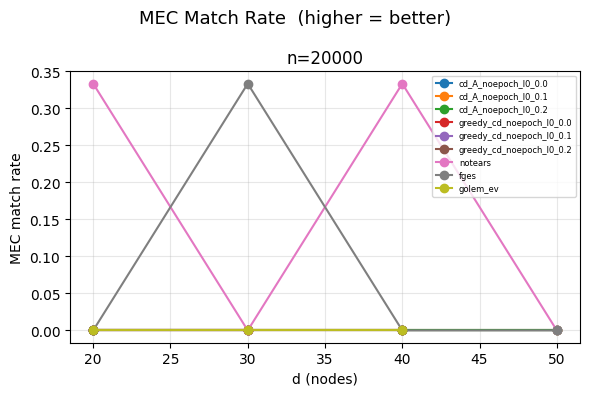

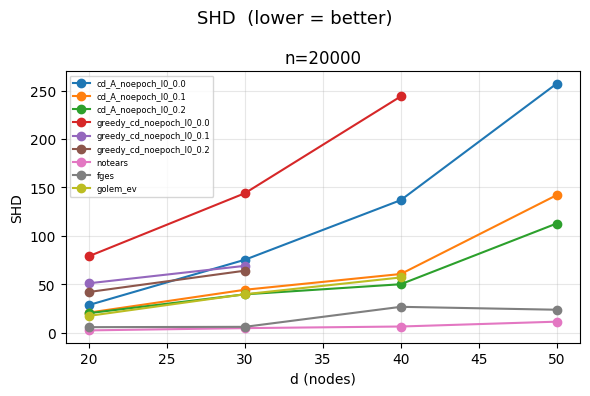

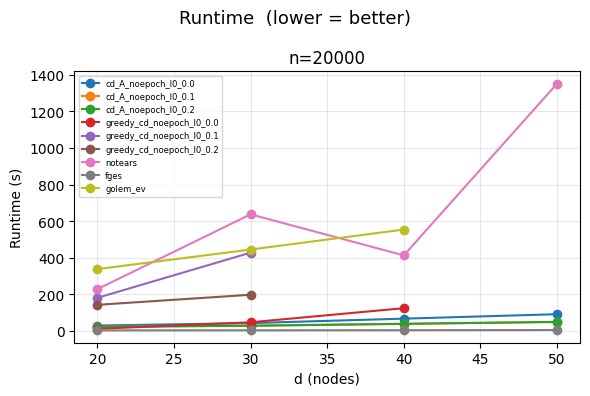

: 

In [ ]:
# 12) 可视化：MEC match rate / SHD / runtime（按 n_samples 分面）
# ──────────────────────────────────────────────────────────────────────────────

if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
    print('请先运行 Cell 10。')
else:
    _n_vals = sorted(df_all_trials['n_samples'].unique())
    _algs   = [a for a in ALGORITHM_ORDER if a in df_all_trials['algorithm'].unique()]

    for _metric, _ylabel, _title in [
        ('mec_match',   'MEC match rate', 'MEC Match Rate  (higher = better)'),
        ('shd',         'SHD',            'SHD  (lower = better)'),
        ('runtime_sec', 'Runtime (s)',     'Runtime  (lower = better)'),
    ]:
        fig, axes = plt.subplots(1, len(_n_vals), figsize=(6 * len(_n_vals), 4),
                                 sharey=True, squeeze=False)
        for _ci, _n in enumerate(_n_vals):
            ax   = axes[0][_ci]
            _sub = df_all_trials[df_all_trials['n_samples'] == _n]
            _agg = _sub.groupby(['d', 'algorithm'])[_metric].mean().reset_index()
            for _a in _algs:
                _vals = _agg[_agg['algorithm'] == _a]
                ax.plot(_vals['d'], _vals[_metric], marker='o', label=_a)
            ax.set_title(f'n={_n}')
            ax.set_xlabel('d (nodes)')
            if _ci == 0:
                ax.set_ylabel(_ylabel)
            ax.legend(fontsize=6, loc='best')
            ax.grid(True, alpha=0.3)
        fig.suptitle(_title, fontsize=13)
        plt.tight_layout()
        plt.show()


In [ ]:
# 13) 跳过记录分析
# ──────────────────────────────────────────────────────────────────────────────

if _SKIP_LOGS:
    df_skips = pd.DataFrame(_SKIP_LOGS)
    print(f'Total skips: {len(df_skips)}')
    display(df_skips.groupby('algorithm')['reason'].value_counts().rename('count').reset_index())
else:
    print('No skips -- 所有算法在全部 trial 上均成功运行。')


No skips -- 所有算法在全部 trial 上均成功运行。
